In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dropout, BatchNormalization, Flatten, Dense
import keras
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# Load the dataset
df = pd.read_csv('Ansa_7thjune.csv')
#df = pd.read_csv('Ansa_7thjune_2nd_iteration.csv')
dataframe = pd.DataFrame(df)
print('data frame',df)

# Split the data into features (X) and labels (y)
x = dataframe.iloc[:,1:2].values
y = dataframe.iloc[:,2:3].values

#x = df.dropna(df[:1])
print('X values', x)
print('Y values', y)
print('shape of x',np.shape(x))
print('shape of y',np.shape(y))

# Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print('x train', x_train)
print('y train', y_train)


data frame       Serial   emg  label
0          1  1501      0
1          2  1569      0
2          3  1552      0
3          4  1554      0
4          5  1527      0
...      ...   ...    ...
5495    5496  1680      0
5496    5497  1730      0
5497    5498  1694      0
5498    5499  1747      0
5499    5500  1685      0

[5500 rows x 3 columns]
X values [[1501]
 [1569]
 [1552]
 ...
 [1694]
 [1747]
 [1685]]
Y values [[0]
 [0]
 [0]
 ...
 [0]
 [0]
 [0]]
shape of x (5500, 1)
shape of y (5500, 1)
x train [[1907]
 [1845]
 [1695]
 ...
 [1904]
 [1721]
 [1662]]
y train [[0]
 [1]
 [0]
 ...
 [0]
 [0]
 [0]]


In [12]:
import tensorflow as tf

from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

# Define the model architecture

model = tf.keras.Sequential([

    tf.keras.layers.Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(100, 1),padding="same"),
    
    tf.keras.layers.Conv1D(filters=64, kernel_size=3, activation='relu', padding="same"),
    
    tf.keras.layers.Conv1D(filters=128, kernel_size=3, activation='relu', padding="same"),
    
    tf.keras.layers.Conv1D(filters=256, kernel_size=3, activation='relu', padding="same"),

    tf.keras.layers.GlobalAveragePooling1D(data_format="channels_last"),

    tf.keras.layers.Dense(256, activation='relu'),

    tf.keras.layers.Dense(1, activation='sigmoid')

])
print(model.summary())


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_7 (Conv1D)               │ (None, 100, 32)        │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 100, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 100, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_10 (Conv1D)              │ (None, 100, 256)       │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_4      │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 195,649 (764.25 KB)

 Trainable params: 195,649 (764.25 KB)

 Non-trainable params: 0 (0.00 B)

None


In [13]:
# Compile the model

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model

history =  model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=500, batch_size=64)

# write history into csv file

Epoch 1/500
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5142 - loss: 1.5965 - val_accuracy: 0.4145 - val_loss: 0.6993
Epoch 2/500
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5286 - loss: 0.7041 - val_accuracy: 0.5855 - val_loss: 0.6849
Epoch 3/500
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5357 - loss: 0.7039 - val_accuracy: 0.5891 - val_loss: 0.6779
Epoch 4/500
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5458 - loss: 0.6895 - val_accuracy: 0.5864 - val_loss: 0.6719
Epoch 5/500
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5572 - loss: 0.6845 - val_accuracy: 0.4182 - val_loss: 0.6874
Epoch 6/500
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5783 - loss: 0.6771 - val_accuracy: 0.6773 - val_loss: 0.6667
Epoch 7/500
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6031 - loss: 0.6698 - val_accuracy: 0.6264 - val_loss: 0.6616
Epoch 8/500
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6322 - loss: 0.6634 - val_accuracy: 0.6764 - v

In [20]:
import pandas as pd

# Save history to a CSV file
history_df = pd.DataFrame(history.history)
history_df.to_csv('history.csv')

In [ ]:
'''import pandas as pd
import matplotlib.pyplot as plt

# Load Data
df = pd.read_csv('history.csv')

# Plot Accuracy
plt.figure(figsize=(8, 6))
plt.plot(df['serial'], df['accuracy'], label='Accuracy', color='blue')
plt.xlabel('Serial')
plt.ylabel('Accuracy')
plt.title('Model performance for accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot Loss
plt.figure(figsize=(8, 6))
plt.plot(df['serial'], df['loss'], label='Loss', color='red')
plt.xlabel('Serial')
plt.ylabel('Loss')
plt.title('Model performance for loss')
plt.legend()
plt.grid(True)
plt.show()

# Plot Validation Accuracy
plt.figure(figsize=(8, 6))
plt.plot(df['serial'], df['val_accuracy'], label='Validation Accuracy', color='green')
plt.xlabel('Serial')
plt.ylabel('Validation Accuracy')
plt.title('Model performance for validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot Validation Loss
plt.figure(figsize=(8, 6))
plt.plot(df['serial'], df['val_loss'], label='Validation Loss', color='purple')
plt.xlabel('Serial')
plt.ylabel('Validation Loss')
plt.title('Model performance for validation Loss')
plt.legend()
plt.grid(True)
plt.show()
'''


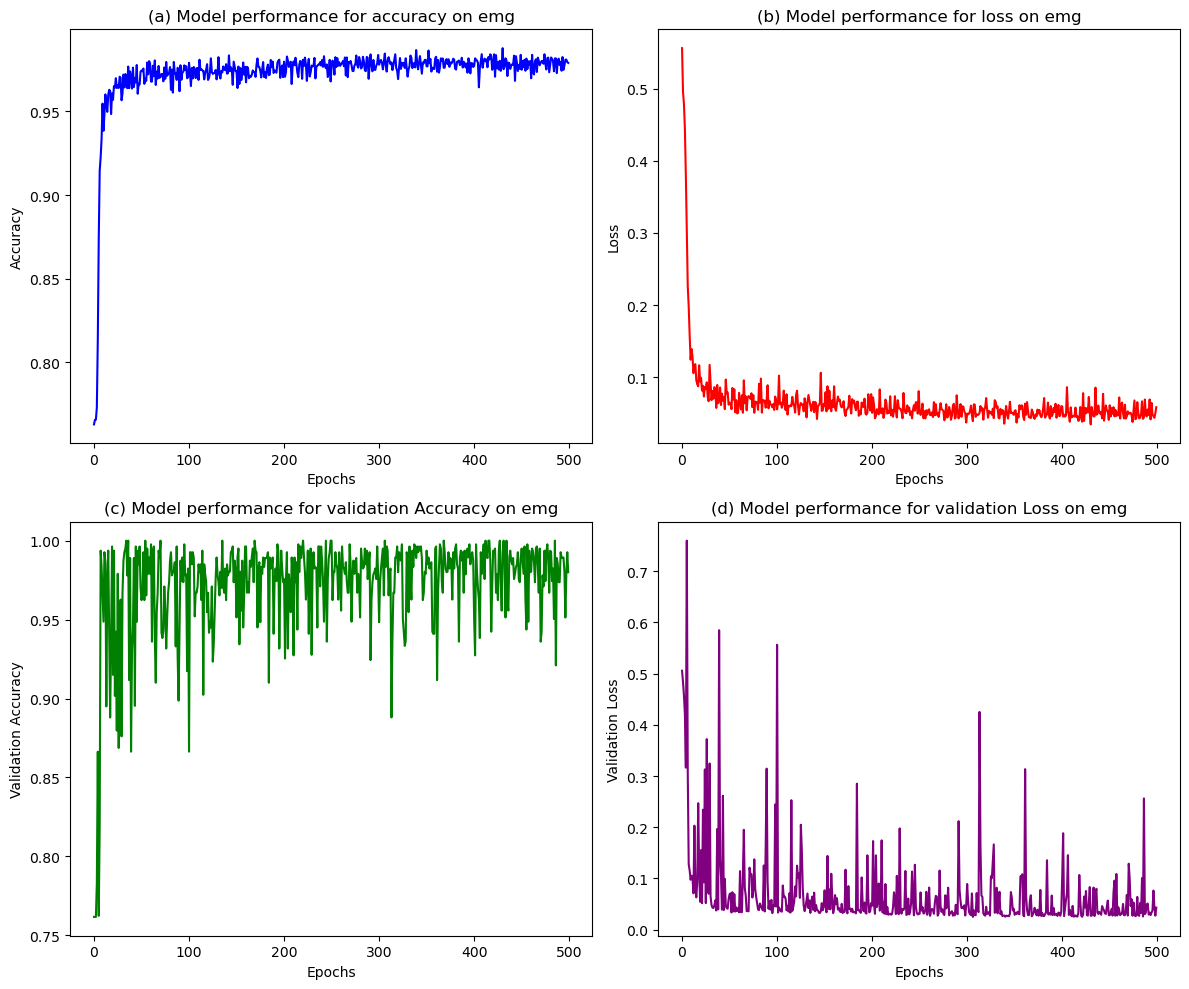

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Data
df = pd.read_csv('history.csv')

# Create a 2x2 subplot layout
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Plot Accuracy
axs[0, 0].plot(df['serial'], df['accuracy'], label='Accuracy', color='blue')
axs[0, 0].set_xlabel('Epochs')
axs[0, 0].set_ylabel('Accuracy')
axs[0, 0].set_title('(a) Model performance for accuracy on emg')

# Plot Loss
axs[0, 1].plot(df['serial'], df['loss'], label='Loss', color='red')
axs[0, 1].set_xlabel('Epochs')
axs[0, 1].set_ylabel('Loss')
axs[0, 1].set_title('(b) Model performance for loss on emg')

# Plot Validation Accuracy
axs[1, 0].plot(df['serial'], df['val_accuracy'], label='Validation Accuracy', color='green')
axs[1, 0].set_xlabel('Epochs')
axs[1, 0].set_ylabel('Validation Accuracy')
axs[1, 0].set_title('(c) Model performance for validation Accuracy on emg')

# Plot Validation Loss
axs[1, 1].plot(df['serial'], df['val_loss'], label='Validation Loss', color='purple')
axs[1, 1].set_xlabel('Epochs')
axs[1, 1].set_ylabel('Validation Loss')
axs[1, 1].set_title('(d) Model performance for validation Loss on emg')

# Adjust layout
plt.tight_layout()

# Show plots
plt.show()


In [25]:
predicted_outcome = model.predict(x_test)
#predicted_outcome and x_test save into csv
#predicted_outcome (predicted result vs. x_test)
#print('predicted_outcome', predicted_outcome)

import pandas as pd

# Create a pandas DataFrame with x_test and predicted_outcome
data = {'x_test': x_test.flatten(), 'predicted_outcome': predicted_outcome.flatten()}
df = pd.DataFrame(data)

# Save the DataFrame to a CSV file
df.to_csv('x_test_predicted_outcome.csv', index=False)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 430us/step


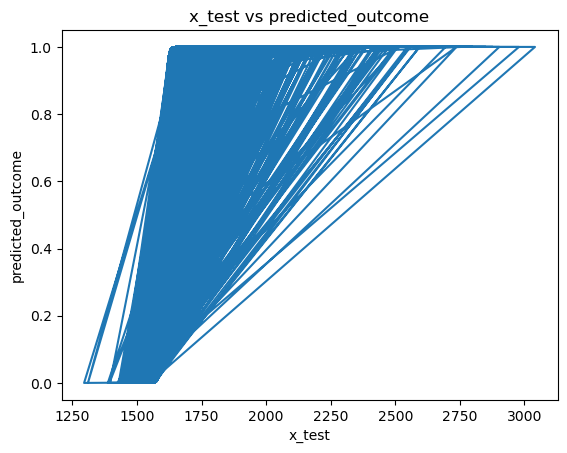

In [23]:
#plot outcome (predicted outcome), x_test vs. predicted_outcome
import matplotlib.pyplot as plt

plt.plot(x_test, predicted_outcome)
plt.xlabel('x_test')
plt.ylabel('predicted_outcome')
plt.title('x_test vs predicted_outcome')
plt.show()

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Predict outcomes
y_train_pred = model.predict(x_train)
y_test_pred = model.predict(x_test)

# Calculate MSE and MAE for training and testing data
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

print(f"Training mean squared error: {train_mse}")
print(f"Testing mean squared error: {test_mse}")
print(f"Training mean absolute error: {train_mae}")
print(f"Testing mean absolute error: {test_mae}")



375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 367us/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 351us/step
Training mean squared error: 0.006103247312119211
Testing mean squared error: 0.0061232645772457605
Training mean absolute error: 0.019192800816356246
Testing mean absolute error: 0.02003468908888036


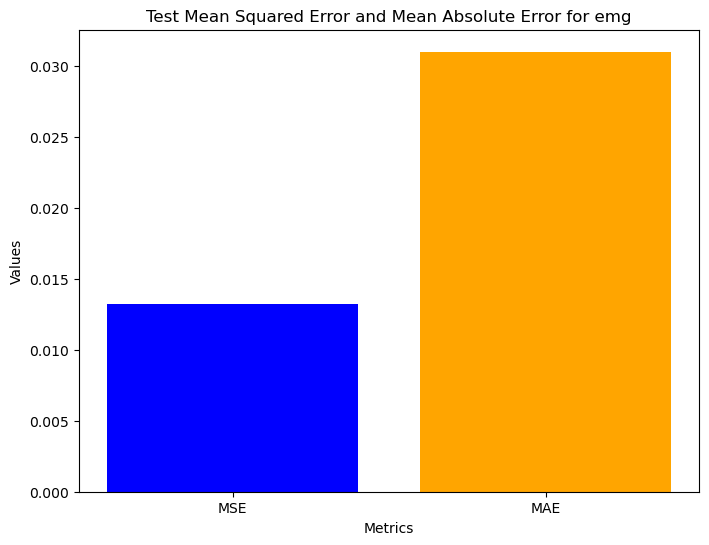

In [15]:
metrics = ['MSE', 'MAE']
values = [test_mse, test_mae]

plt.figure(figsize=(8, 6))
plt.bar(metrics, values, color=['blue', 'orange'])
plt.xlabel('Metrics')
plt.ylabel('Values')
plt.title('Test Mean Squared Error and Mean Absolute Error for emg')
plt.show()

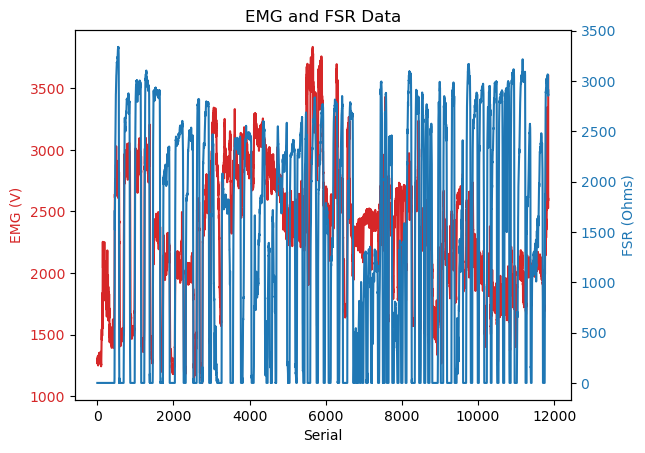

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the CSV file
df = pd.read_csv('amna training 1.csv')

# Extract data from DataFrame
serial = df['serial']
emg = df['emg']
fsr = df['fsr']

# Plotting
fig, ax1 = plt.subplots()

# Plot EMG data
color = 'tab:red'
ax1.set_xlabel('Serial')
ax1.set_ylabel('EMG (V)', color=color)
ax1.plot(serial, emg, color=color)
ax1.tick_params(axis='y', labelcolor=color)

# Create a second y-axis for FSR data
ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('FSR (Ohms)', color=color)
ax2.plot(serial, fsr, color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('EMG and FSR Data')
plt.show()



In [ ]:
'''from sklearn.preprocessing import StandardScaler
import pandas as pd

# Load CSV data
df = pd.read_csv('Ansa training without headers.csv', header=None)

# Display original data
print("Original Data:")
print(df)

# Perform scaling
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# Display mean of each feature
print("\nMean of each feature after scaling:")
print(scaler.mean_)

# Display scaled data
print("\nScaled Data:")
print(scaled_data)'''


In [ ]:
'''# Transform new data
new_data = [[1]]
scaled_new_data = scaler.transform(new_data)

# Display transformed new data
print("\nTransformed new data:")
print(scaled_new_data)'''

In [28]:
#load StandardScaler
from sklearn.preprocessing import StandardScaler

#load x_train data from CSV file
x_train = pd.read_csv('Ansa training without headers.csv')

#create scaler object
scalery = StandardScaler().fit(x_train)

#transform the x_test data
x_test = pd.read_csv('Ansa training without headers.csv')
x_test = scalery.transform(x_test)

# print transformed x_test
print("this is the scaled array:\n",x_test)

#inverse the x_test data back to original values
x_new = pd.DataFrame(x_test, columns =['x_new'])
x_new_inverse = scalery.inverse_transform(x_new)

# print inversed to original x_test
print("\nthis is the inversed array:\n",x_new_inverse)

this is the scaled array:
 [[-1.16127221]
 [-0.84097427]
 [-0.92104875]
 ...
 [ 2.55041568]
 [ 2.85658283]
 [ 3.4971787 ]]

this is the inversed array:
 [[1501.]
 [1569.]
 [1552.]
 ...
 [2289.]
 [2354.]
 [2490.]]


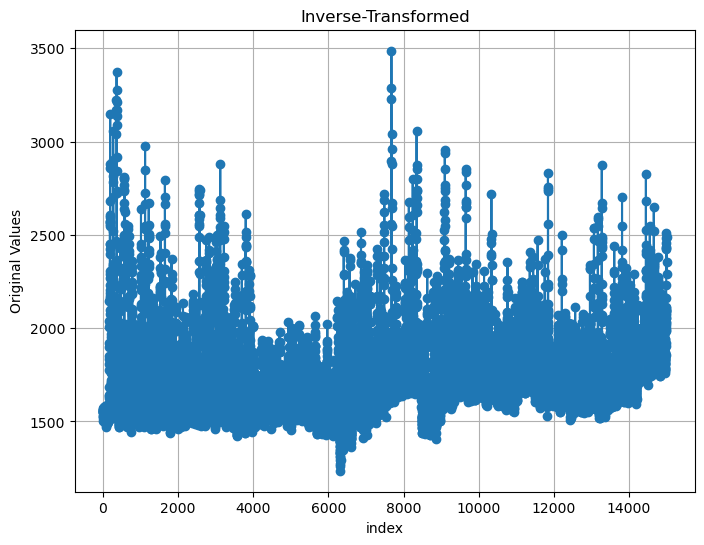

In [29]:
import matplotlib.pyplot as plt

# plot the inverse-transformed x_test data
plt.figure(figsize=(8, 6))
plt.plot(range(len(x_new_inverse)), x_new_inverse, marker='o')
plt.xlabel('index')
plt.ylabel('Original Values')
plt.title('Inverse-Transformed')
plt.grid(True)
plt.show()